In [ ]:
from IPython.display import display
# Imports and reproducibility settings
import warnings
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from statsmodels.tsa.stattools import adfuller
    STATSMODELS_AVAILABLE = True
except Exception:
    STATSMODELS_AVAILABLE = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


FORECAST_HORIZON = 7
TEST_FRACTION = 0.15
VALID_FRACTION = 0.15

print('Notebook run time:', datetime.now().strftime('%Y-%m-%d %H:%M:%S'))
print('XGBoost available:', XGBOOST_AVAILABLE)
print('Statsmodels available:', STATSMODELS_AVAILABLE)

Notebook run time: 2026-05-11 12:49:15
XGBoost available: True
Statsmodels available: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

def find_first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

candidate_files = [
    Path('/content/drive/MyDrive/36100_DSI/Assessment2/cleaned_merged_brent_macro_data_2014_2024.csv')
]


csv_path = find_first_existing(candidate_files)

if csv_path is None:
    raise FileNotFoundError(
        'No dataset found.'
    )

raw_df = pd.read_csv(csv_path)
print('Loaded file:', csv_path.name)
print('Raw shape:', raw_df.shape)
display(raw_df.head())


Mounted at /content/drive
Loaded file: cleaned_merged_brent_macro_data_2014_2024.csv
Raw shape: (2769, 6)


,Date,Brent_Close,Gold_Close,USD_Index_Close,SP500_Close,VIX_Close
0,2014-01-02,107.779999,1225.000000,80.629997,1831.979980,14.23
1,2014-01-03,106.889999,1238.400024,80.790001,1831.369995,13.76
2,2014-01-06,106.730003,1237.800049,80.650002,1826.770020,13.55
3,2014-01-07,107.349998,1229.400024,80.830002,1837.880005,12.92
4,2014-01-08,107.150002,1225.300049,81.040001,1837.489990,12.87


In [ ]:
# 2. Cleaning and explicit missing-value report

# Make a copy of the raw dataset
clean_df = raw_df.copy()

clean_df.columns = [str(c).strip().replace(" ", "_") for c in clean_df.columns]

required_columns = [
    "Date",
    "Brent_Close",
    "Gold_Close",
    "USD_Index_Close",
    "SP500_Close",
    "VIX_Close"
]

missing_required_columns = [
    col for col in required_columns if col not in clean_df.columns
]

if missing_required_columns:
    raise ValueError(
        f"The dataset is missing required columns: {missing_required_columns}. "
        "Please use cleaned_merged_brent_macro_data_2014_2024.csv."
    )

# Keep only the required columns in the correct order
clean_df = clean_df[required_columns].copy()

clean_df["Date"] = pd.to_datetime(clean_df["Date"], errors="coerce")

for col in required_columns:
    if col != "Date":
        clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

missing_before = clean_df.isna().sum().rename("missing_before_cleaning")
duplicate_dates_before = clean_df.duplicated(subset=["Date"]).sum()

print("Initial shape:", clean_df.shape)
print("Duplicate dates before cleaning:", duplicate_dates_before)
print("Missing values before cleaning:")
display(missing_before.to_frame())

# Remove rows with invalid dates
clean_df = clean_df.dropna(subset=["Date"])

# Sort by date to preserve time-series order
clean_df = clean_df.sort_values("Date")

# Remove duplicate dates, keeping the latest available row
clean_df = clean_df.drop_duplicates(subset=["Date"], keep="last")

value_cols = [col for col in clean_df.columns if col != "Date"]
clean_df[value_cols] = clean_df[value_cols].ffill()

# Drop remaining missing rows, usually at the beginning if any series starts later
clean_df = clean_df.dropna().reset_index(drop=True)

missing_after = clean_df.isna().sum().rename("missing_after_cleaning")

missing_table = pd.concat(
    [missing_before, missing_after],
    axis=1
).fillna(0).astype(int)

print("Final cleaned shape:", clean_df.shape)
print("Date range:", clean_df["Date"].min().date(), "to", clean_df["Date"].max().date())
print("Duplicate dates after cleaning:", clean_df.duplicated(subset=["Date"]).sum())

print("\nMissing-value summary:")
display(missing_table)

print("\nCleaned dataset preview:")
display(clean_df.head())

print("\nCleaned dataset tail:")
display(clean_df.tail())

Initial shape: (2769, 6)
Duplicate dates before cleaning: 0
Missing values before cleaning:


,missing_before_cleaning
Date,0
Brent_Close,0
Gold_Close,0
USD_Index_Close,0
SP500_Close,0
VIX_Close,0


Final cleaned shape: (2769, 6)
Date range: 2014-01-02 to 2024-12-30
Duplicate dates after cleaning: 0

Missing-value summary:


,missing_before_cleaning,missing_after_cleaning
Date,0,0
Brent_Close,0,0
Gold_Close,0,0
USD_Index_Close,0,0
SP500_Close,0,0
VIX_Close,0,0



Cleaned dataset preview:


,Date,Brent_Close,Gold_Close,USD_Index_Close,SP500_Close,VIX_Close
0,2014-01-02,107.779999,1225.000000,80.629997,1831.979980,14.23
1,2014-01-03,106.889999,1238.400024,80.790001,1831.369995,13.76
2,2014-01-06,106.730003,1237.800049,80.650002,1826.770020,13.55
3,2014-01-07,107.349998,1229.400024,80.830002,1837.880005,12.92
4,2014-01-08,107.150002,1225.300049,81.040001,1837.489990,12.87



Cleaned dataset tail:


,Date,Brent_Close,Gold_Close,USD_Index_Close,SP500_Close,VIX_Close
2764,2024-12-23,72.629997,2612.300049,108.040001,5974.069824,16.780001
2765,2024-12-24,73.580002,2620.000000,108.260002,6040.040039,14.270000
2766,2024-12-26,73.260002,2638.800049,108.129997,6037.589844,14.730000
2767,2024-12-27,74.169998,2617.199951,108.000000,5970.839844,15.950000
2768,2024-12-30,74.389999,2606.100098,108.129997,5906.939941,17.400000


,series,adf_statistic,p_value,interpretation
0,Brent_Close price level,-2.277415,1.793556e-01,Non-stationary
1,Brent percentage return,-9.927528,2.880407e-17,Stationary
2,Brent log return,-9.905994,3.262480e-17,Stationary


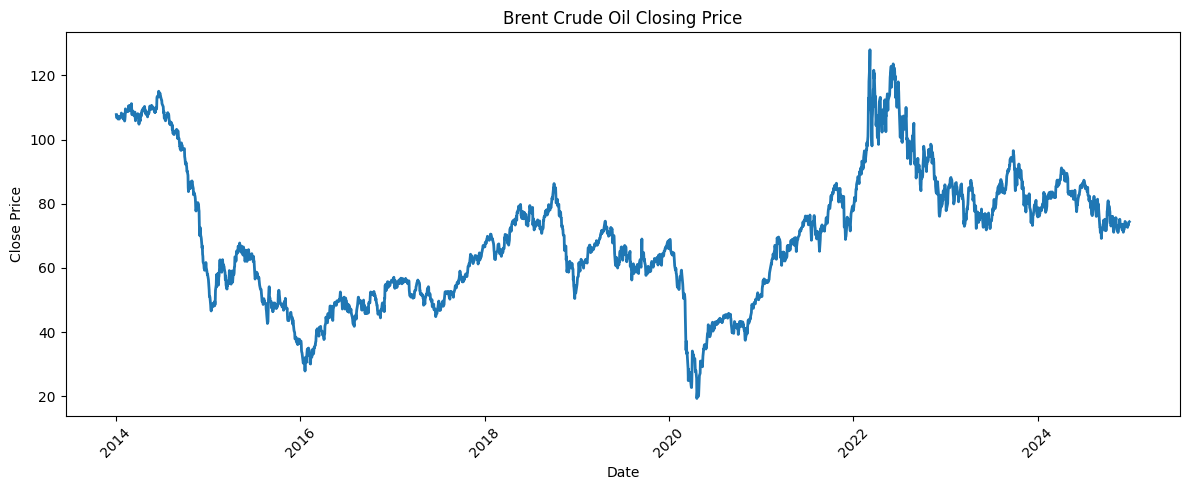

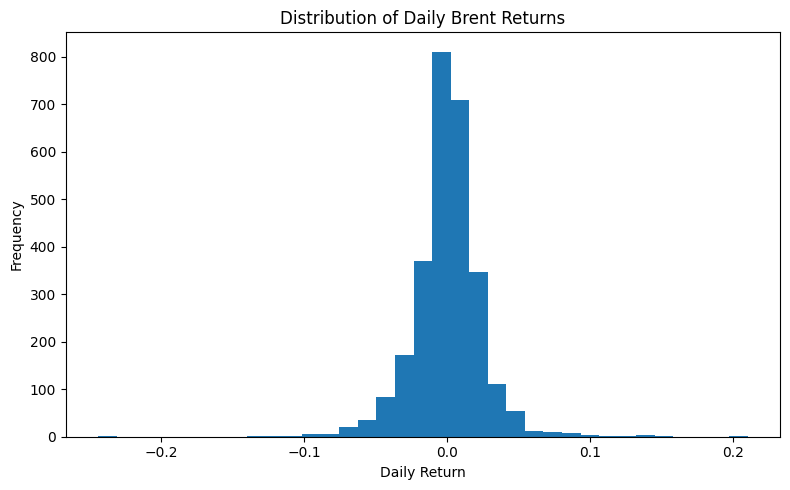

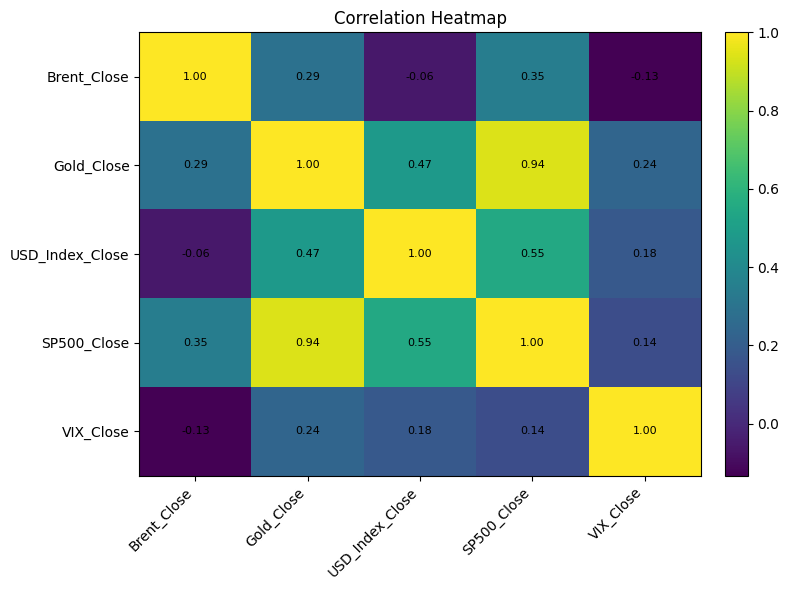

In [ ]:
# 3. EDA + stationarity checks

def adf_test(series: pd.Series, name: str) -> dict:
    series = pd.Series(series).dropna()
    if len(series) < 20 or not STATSMODELS_AVAILABLE:
        return {
            'series': name,
            'adf_statistic': np.nan,
            'p_value': np.nan,
            'interpretation': 'Not enough data or statsmodels unavailable'
        }
    result = adfuller(series, autolag='AIC')
    p_value = result[1]
    return {
        'series': name,
        'adf_statistic': result[0],
        'p_value': p_value,
        'interpretation': 'Stationary' if p_value < 0.05 else 'Non-stationary'
    }

brent_col = 'Brent_Close'
if brent_col not in clean_df.columns:
    raise ValueError('Brent_Close column is required as target variable.')

eda_df = clean_df.copy()
eda_df['Brent_Return'] = eda_df[brent_col].pct_change()
eda_df['Brent_Log_Return'] = np.log(eda_df[brent_col]).diff()

adf_results = pd.DataFrame([
    adf_test(eda_df[brent_col], 'Brent_Close price level'),
    adf_test(eda_df['Brent_Return'], 'Brent percentage return'),
    adf_test(eda_df['Brent_Log_Return'], 'Brent log return'),
])

display(adf_results)

# Brent price trend
plt.figure(figsize=(12, 5))
plt.plot(clean_df['Date'], clean_df[brent_col], linewidth=2)
plt.title('Brent Crude Oil Closing Price')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Return distribution
plt.figure(figsize=(8, 5))
plt.hist(eda_df['Brent_Return'].dropna(), bins=35)
plt.title('Distribution of Daily Brent Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Correlation heatmap without seaborn dependency
num_cols = [c for c in clean_df.columns if c != 'Date']
if len(num_cols) >= 2:
    corr = clean_df[num_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(corr.values, aspect='auto')
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(corr.index)))
    ax.set_yticklabels(corr.index)
    for i in range(len(corr.index)):
        for j in range(len(corr.columns)):
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    ax.set_title('Correlation Heatmap')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

In [ ]:
# 4. Feature engineering

def add_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

model_df = clean_df.copy()
model_df['target_7d_ahead'] = model_df[brent_col].shift(-FORECAST_HORIZON)
model_df['current_close'] = model_df[brent_col]

# Price-based features
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    model_df[f'Brent_lag_{lag}'] = model_df[brent_col].shift(lag)
    model_df[f'Brent_return_lag_{lag}'] = model_df[brent_col].pct_change(lag)

for window in [3, 7, 14, 21, 30]:
    model_df[f'Brent_MA_{window}'] = model_df[brent_col].rolling(window).mean()
    model_df[f'Brent_STD_{window}'] = model_df[brent_col].rolling(window).std()
    model_df[f'Brent_ROC_{window}'] = model_df[brent_col].pct_change(window)

# Technical indicators
model_df['Brent_RSI_14'] = add_rsi(model_df[brent_col], window=14)
model_df['Brent_BB_MID_20'] = model_df[brent_col].rolling(20).mean()
model_df['Brent_BB_STD_20'] = model_df[brent_col].rolling(20).std()
model_df['Brent_BB_width_20'] = (4 * model_df['Brent_BB_STD_20']) / model_df['Brent_BB_MID_20']
model_df['Brent_EMA_12'] = model_df[brent_col].ewm(span=12, adjust=False).mean()
model_df['Brent_EMA_26'] = model_df[brent_col].ewm(span=26, adjust=False).mean()
model_df['Brent_MACD'] = model_df['Brent_EMA_12'] - model_df['Brent_EMA_26']

# Calendar features
model_df['day_of_week'] = model_df['Date'].dt.dayofweek
model_df['month'] = model_df['Date'].dt.month
model_df['quarter'] = model_df['Date'].dt.quarter

# Add transformations for any macro/financial indicators if present
macro_cols = [c for c in model_df.columns if c not in ['Date', 'target_7d_ahead'] and c.endswith('_Close') and c != brent_col]
for col in macro_cols:
    model_df[f'{col}_return_1'] = model_df[col].pct_change(1)
    model_df[f'{col}_return_7'] = model_df[col].pct_change(7)
    model_df[f'{col}_lag_1'] = model_df[col].shift(1)
    model_df[f'{col}_MA_7'] = model_df[col].rolling(7).mean()

feature_df = model_df.dropna().reset_index(drop=True)

non_feature_cols = ['Date', 'target_7d_ahead']
feature_cols = [c for c in feature_df.columns if c not in non_feature_cols]

print('Rows after feature engineering:', feature_df.shape[0])
print('Number of features:', len(feature_cols))
print('Macro columns detected:', macro_cols if macro_cols else 'None - using Brent OHLC/technical features only')
display(feature_df[['Date', brent_col, 'target_7d_ahead'] + feature_cols[:8]].head())

Rows after feature engineering: 2732
Number of features: 63
Macro columns detected: ['Gold_Close', 'USD_Index_Close', 'SP500_Close', 'VIX_Close']


,Date,Brent_Close,target_7d_ahead,Brent_Close,Gold_Close,USD_Index_Close,SP500_Close,VIX_Close,current_close,Brent_lag_1,Brent_return_lag_1
0,2014-02-14,108.730003,109.519997,108.730003,1319.000000,80.129997,1838.630005,13.57,108.730003,108.730003,0.000000
1,2014-02-18,108.730003,108.959999,108.730003,1324.699951,80.010002,1840.760010,13.87,108.730003,108.730003,0.000000
2,2014-02-19,110.470001,109.070000,110.470001,1320.599976,80.169998,1828.750000,15.50,110.470001,108.730003,0.016003
3,2014-02-20,110.300003,111.199997,110.300003,1317.099976,80.290001,1839.780029,14.79,110.300003,110.470001,-0.001539
4,2014-02-21,109.849998,109.300003,109.849998,1323.900024,80.239998,1836.250000,14.68,109.849998,110.300003,-0.004080


In [ ]:
# 5. Chronological train / validation / test split

n = len(feature_df)
if n < 80:
    raise ValueError('Not enough rows after feature engineering. At least ~80 rows are recommended.')

test_size = max(int(n * TEST_FRACTION), FORECAST_HORIZON * 3)
valid_size = max(int(n * VALID_FRACTION), FORECAST_HORIZON * 3)
train_size = n - valid_size - test_size

if train_size <= 50:
    # Keep a workable split for smaller datasets.
    train_size = int(n * 0.70)
    valid_size = int(n * 0.15)
    test_size = n - train_size - valid_size

train_df = feature_df.iloc[:train_size].copy()
valid_df = feature_df.iloc[train_size:train_size + valid_size].copy()
test_df = feature_df.iloc[train_size + valid_size:].copy()

X_train, y_train = train_df[feature_cols], train_df['target_7d_ahead']
X_valid, y_valid = valid_df[feature_cols], valid_df['target_7d_ahead']
X_test, y_test = test_df[feature_cols], test_df['target_7d_ahead']

print('Train period:', train_df['Date'].min().date(), 'to', train_df['Date'].max().date(), '| rows:', len(train_df))
print('Valid period:', valid_df['Date'].min().date(), 'to', valid_df['Date'].max().date(), '| rows:', len(valid_df))
print('Test period :', test_df['Date'].min().date(), 'to', test_df['Date'].max().date(), '| rows:', len(test_df))

Train period: 2014-02-14 to 2021-09-20 | rows: 1914
Valid period: 2021-09-21 to 2023-05-05 | rows: 409
Test period : 2023-05-08 to 2024-12-18 | rows: 409


In [ ]:
# 6. Model training and validation selection

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    return float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100)

def directional_accuracy(current_close, y_true, y_pred):

    true_direction = np.where(
        np.asarray(y_true) > np.asarray(current_close),
        1,
        -1
    )

    pred_direction = np.where(
        np.asarray(y_pred) > np.asarray(current_close),
        1,
        -1
    )

    return float(np.mean(true_direction == pred_direction) * 100)
def evaluate_predictions(name, split_name, y_true, y_pred, current_close):
    return {
        'model': name,
        'split': split_name,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'MAPE_%': mape(y_true, y_pred),
        'R2': r2_score(y_true, y_pred),
        'Directional_Accuracy_%': directional_accuracy(current_close, y_true, y_pred)
    }

models = {}

models['Naive_Persistence'] = None

models['Ridge_Regression'] = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-4, 4, 25)))
])

models['Random_Forest'] = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=8,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

if XGBOOST_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
    n_estimators=80,
    learning_rate=0.02,
    max_depth=2,
    min_child_weight=8,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
else:
    models['Gradient_Boosting_Fallback'] = HistGradientBoostingRegressor(
        max_iter=350,
        learning_rate=0.03,
        max_leaf_nodes=15,
        random_state=RANDOM_STATE
    )

# Fit models and evaluate on validation set.
validation_rows = []

for name, model in models.items():
    if name == 'Naive_Persistence':
        valid_pred = valid_df['current_close'].values
    else:
        model.fit(X_train, y_train)
        valid_pred = model.predict(X_valid)
    validation_rows.append(evaluate_predictions(name, 'validation', y_valid, valid_pred, valid_df['current_close']))

validation_results = pd.DataFrame(validation_rows).sort_values('RMSE')
display(validation_results)

best_model_name = validation_results.iloc[0]['model']
print('Best validation model:', best_model_name)

,model,split,MAE,RMSE,MAPE_%,R2,Directional_Accuracy_%
0,Naive_Persistence,validation,4.739560,6.390228,5.124668,0.761739,44.987775
2,Random_Forest,validation,6.692149,8.712429,7.020543,0.557107,48.410758
1,Ridge_Regression,validation,6.858822,8.779984,7.215411,0.550212,45.721271
3,XGBoost,validation,12.447582,14.516864,12.837678,-0.229607,44.987775


Best validation model: Naive_Persistence


In [ ]:
# 7. Final model evaluation on held-out test set

train_valid_df = pd.concat([train_df, valid_df], axis=0).reset_index(drop=True)
X_train_valid = train_valid_df[feature_cols]
y_train_valid = train_valid_df['target_7d_ahead']

final_models = {}
for name, model in models.items():
    if name == 'Naive_Persistence':
        final_models[name] = None
    else:
        model.fit(X_train_valid, y_train_valid)
        final_models[name] = model

test_rows = []
test_predictions = test_df[['Date', 'current_close', 'target_7d_ahead']].copy()

for name, model in final_models.items():
    if name == 'Naive_Persistence':
        test_pred = test_df['current_close'].values
    else:
        test_pred = model.predict(X_test)
    test_predictions[f'pred_{name}'] = test_pred
    test_rows.append(evaluate_predictions(name, 'test', y_test, test_pred, test_df['current_close']))

test_results = pd.DataFrame(test_rows).sort_values('RMSE').reset_index(drop=True)
display(test_results)


best_test_model_name = test_results.iloc[0]['model']
print('Best test model:', best_test_model_name)

,model,split,MAE,RMSE,MAPE_%,R2,Directional_Accuracy_%
0,Ridge_Regression,test,2.644488,3.320526,3.274485,0.679237,55.501222
1,Naive_Persistence,test,2.683716,3.380459,3.324032,0.667553,49.144254
2,Random_Forest,test,3.216880,4.096948,3.946923,0.511695,56.234719
3,XGBoost,test,4.239661,5.191161,5.082271,0.216029,50.855746


Best test model: Ridge_Regression


In [ ]:
# 8. Reliability analysis with bootstrap confidence intervals

def bootstrap_metric_ci(y_true, y_pred, metric_func, n_bootstrap=500, confidence=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    n = len(y_true)
    if n == 0:
        return (np.nan, np.nan)
    scores = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        scores.append(metric_func(y_true[idx], y_pred[idx]))
    lower = np.percentile(scores, (1 - confidence) / 2 * 100)
    upper = np.percentile(scores, (1 + confidence) / 2 * 100)
    return float(lower), float(upper)

ci_rows = []
for name in final_models.keys():
    pred_col = f'pred_{name}'
    preds = test_predictions[pred_col].values
    mae_ci = bootstrap_metric_ci(y_test.values, preds, mean_absolute_error, random_state=RANDOM_STATE)
    rmse_ci = bootstrap_metric_ci(y_test.values, preds, rmse, random_state=RANDOM_STATE)
    ci_rows.append({
        'model': name,
        'MAE_CI_95_lower': mae_ci[0],
        'MAE_CI_95_upper': mae_ci[1],
        'RMSE_CI_95_lower': rmse_ci[0],
        'RMSE_CI_95_upper': rmse_ci[1]
    })

ci_results = pd.DataFrame(ci_rows)
combined_results = test_results.merge(ci_results, on='model', how='left')
display(combined_results)

,model,split,MAE,RMSE,MAPE_%,R2,Directional_Accuracy_%,MAE_CI_95_lower,MAE_CI_95_upper,RMSE_CI_95_lower,RMSE_CI_95_upper
0,Ridge_Regression,test,2.644488,3.320526,3.274485,0.679237,55.501222,2.437895,2.839256,3.080101,3.541584
1,Naive_Persistence,test,2.683716,3.380459,3.324032,0.667553,49.144254,2.477334,2.879000,3.132021,3.607814
2,Random_Forest,test,3.216880,4.096948,3.946923,0.511695,56.234719,2.999146,3.482200,3.830257,4.397909
3,XGBoost,test,4.239661,5.191161,5.082271,0.216029,50.855746,3.954334,4.519239,4.882609,5.483218


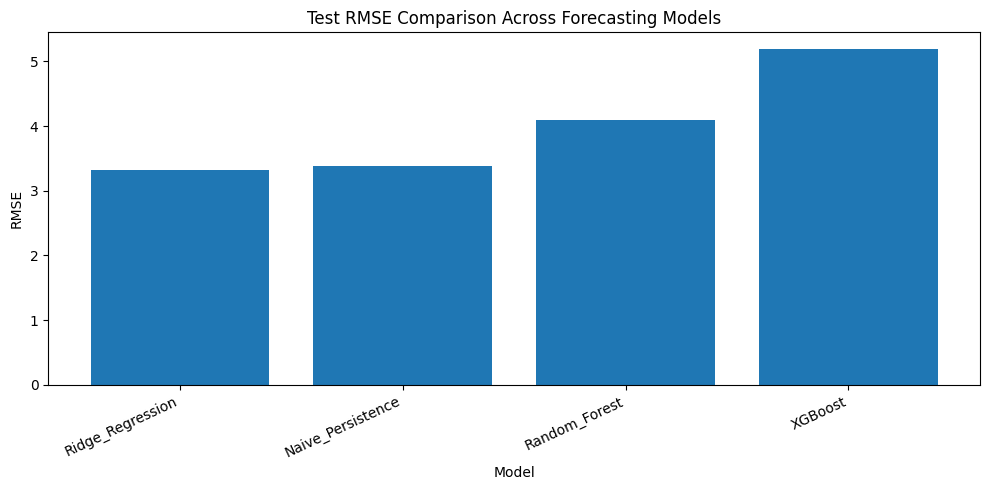

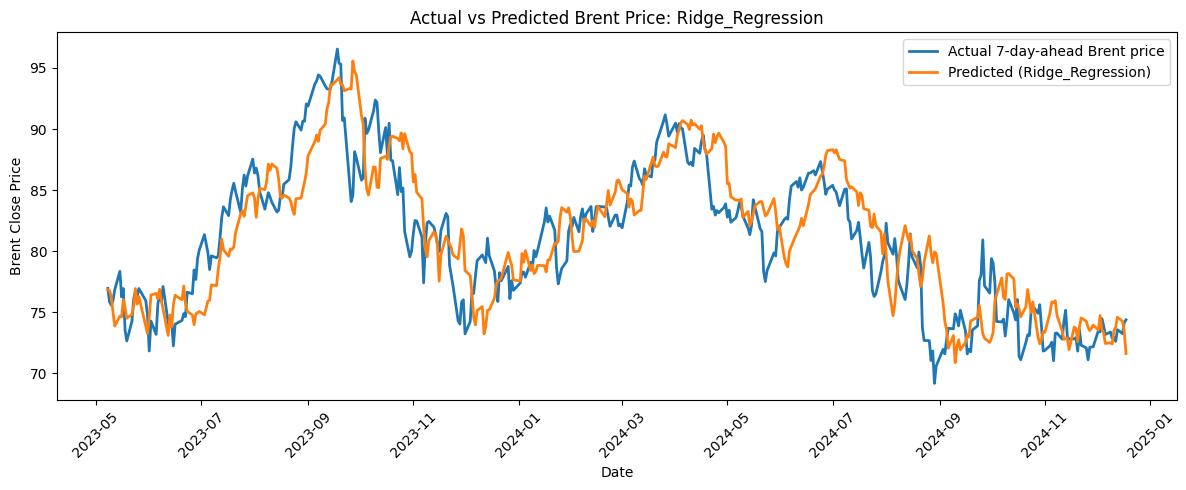

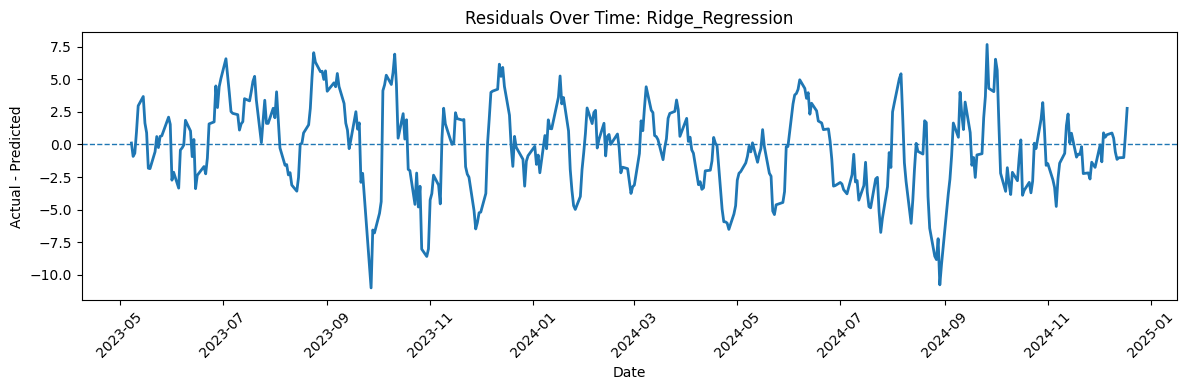

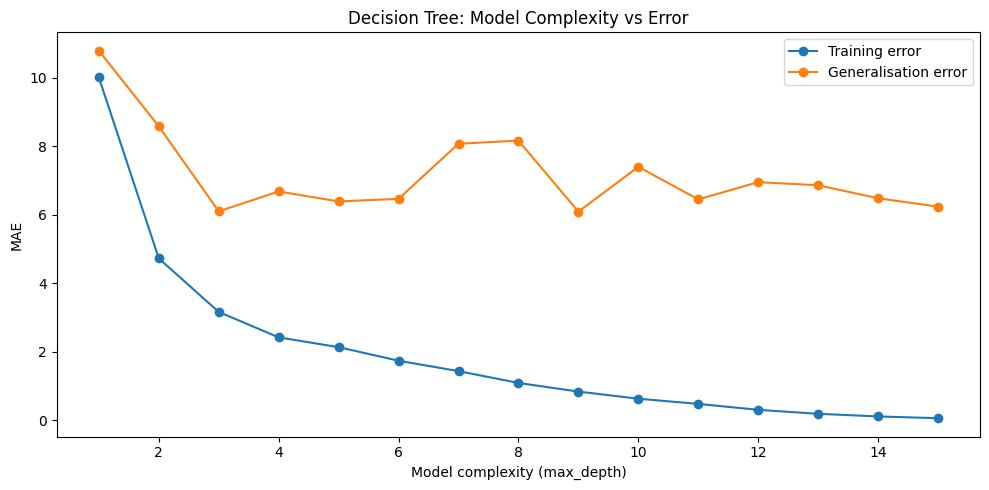

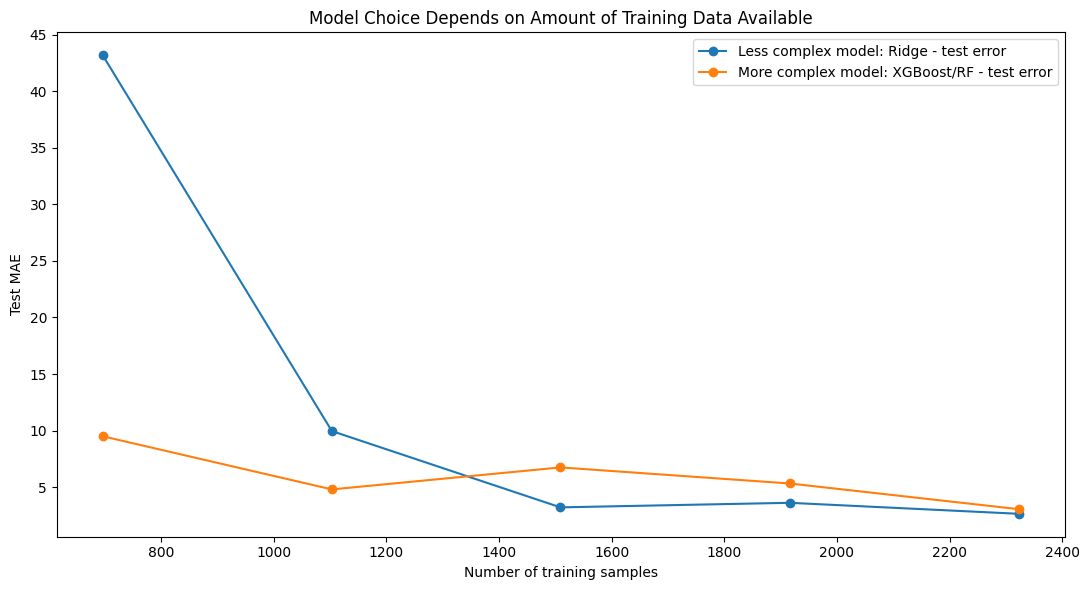

Overall best test model: Ridge_Regression
Best non-naive ML model for feature importance: Ridge_Regression

Top 15 important features:


,feature,importance_mean,importance_std
0,Gold_Close,0.155361,0.019681
1,Gold_Close_lag_1,0.136364,0.017074
2,Brent_STD_30,0.068319,0.015801
3,current_close,0.058109,0.031600
4,Brent_Close,0.058109,0.031600
5,VIX_Close,0.041936,0.011622
6,Brent_lag_5,0.039606,0.028765
7,VIX_Close_return_7,0.029122,0.012791
8,Brent_lag_7,0.027039,0.026051
9,Brent_lag_14,0.026777,0.018081


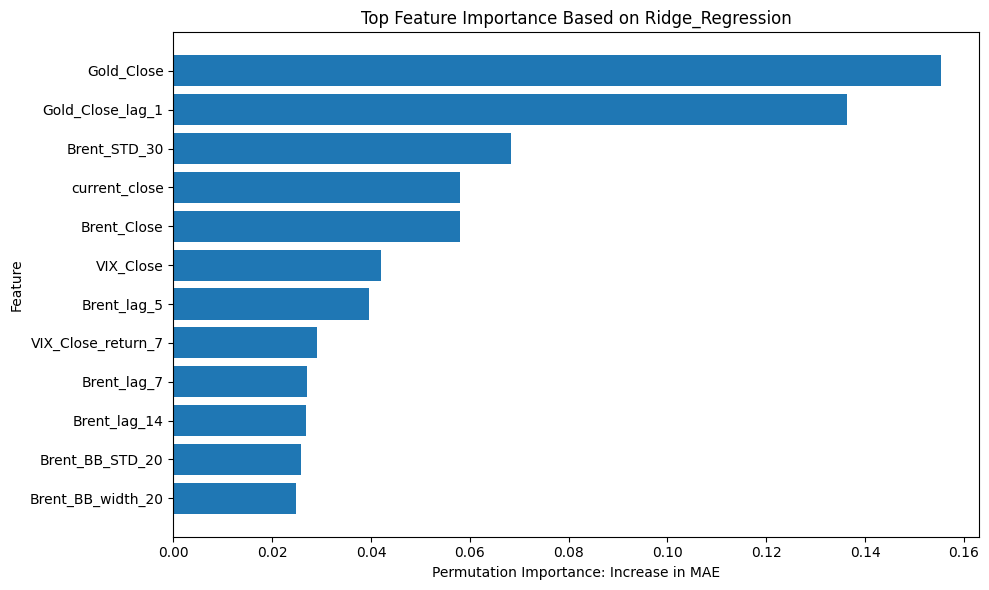


Interpretation:
The feature importance analysis is based on Ridge_Regression, the best-performing non-naive machine learning model. Features with higher permutation importance caused a larger increase in prediction error when shuffled, meaning they contributed more to the model's forecasts.


In [ ]:
# 9. Visualisations

# 9.1 Model comparison
plt.figure(figsize=(10, 5))
ordered = test_results.sort_values('RMSE', ascending=True)
plt.bar(ordered['model'], ordered['RMSE'])
plt.title('Test RMSE Comparison Across Forecasting Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

# 9.2 Actual vs predicted for best model
best_pred_col = f'pred_{best_test_model_name}'
plt.figure(figsize=(12, 5))
plt.plot(test_predictions['Date'], test_predictions['target_7d_ahead'], label='Actual 7-day-ahead Brent price', linewidth=2)
plt.plot(test_predictions['Date'], test_predictions[best_pred_col], label=f'Predicted ({best_test_model_name})', linewidth=2)
plt.title(f'Actual vs Predicted Brent Price: {best_test_model_name}')
plt.xlabel('Date')
plt.ylabel('Brent Close Price')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9.3 Residuals over time
residuals = test_predictions['target_7d_ahead'] - test_predictions[best_pred_col]
plt.figure(figsize=(12, 4))
plt.axhline(0, linestyle='--', linewidth=1)
plt.plot(test_predictions['Date'], residuals, linewidth=2)
plt.title(f'Residuals Over Time: {best_test_model_name}')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9.4 Model complexity / generalisation error curve using Decision Tree
complexity_rows = []
for depth in range(1, 16):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    train_pred = tree.predict(X_train)
    valid_pred = tree.predict(X_valid)
    complexity_rows.append({
        'max_depth': depth,
        'training_error_MAE': mean_absolute_error(y_train, train_pred),
        'generalisation_error_MAE': mean_absolute_error(y_valid, valid_pred)
    })

complexity_df = pd.DataFrame(complexity_rows)
plt.figure(figsize=(10, 5))
plt.plot(complexity_df['max_depth'], complexity_df['training_error_MAE'], marker='o', label='Training error')
plt.plot(complexity_df['max_depth'], complexity_df['generalisation_error_MAE'], marker='o', label='Generalisation error')
plt.title('Decision Tree: Model Complexity vs Error')
plt.xlabel('Model complexity (max_depth)')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

# 9.5 Learning curve: data volume vs error for simple and complex model
fractions = np.linspace(0.30, 1.0, 5)
learning_rows = []

for frac in fractions:
    rows = max(30, int(len(train_valid_df) * frac))
    sub = train_valid_df.iloc[:rows]
    X_sub, y_sub = sub[feature_cols], sub['target_7d_ahead']

    # Less complex model
    simple = Pipeline([('scaler', StandardScaler()), ('model', RidgeCV(alphas=np.logspace(-4, 4, 25)))])
    simple.fit(X_sub, y_sub)
    simple_train_pred = simple.predict(X_sub)
    simple_test_pred = simple.predict(X_test)
    learning_rows.append({
        'training_fraction': frac,
        'training_samples': rows,
        'model_type': 'Less complex model: Ridge',
        'training_error_MAE': mean_absolute_error(y_sub, simple_train_pred),
        'test_error_MAE': mean_absolute_error(y_test, simple_test_pred)
    })

    # More complex model
    if XGBOOST_AVAILABLE:
        complex_model = XGBRegressor(
            n_estimators=100,
            learning_rate=0.04,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.85,
            objective='reg:squarederror',
            random_state=RANDOM_STATE,
            n_jobs=1
        )
    else:
        complex_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=1
        )
    complex_model.fit(X_sub, y_sub)
    complex_train_pred = complex_model.predict(X_sub)
    complex_test_pred = complex_model.predict(X_test)
    learning_rows.append({
        'training_fraction': frac,
        'training_samples': rows,
        'model_type': 'More complex model: XGBoost/RF',
        'training_error_MAE': mean_absolute_error(y_sub, complex_train_pred),
        'test_error_MAE': mean_absolute_error(y_test, complex_test_pred)
    })

learning_df = pd.DataFrame(learning_rows)
plt.figure(figsize=(11, 6))
for model_type in learning_df['model_type'].unique():
    sub = learning_df[learning_df['model_type'] == model_type]
    plt.plot(sub['training_samples'], sub['test_error_MAE'], marker='o', label=f'{model_type} - test error')
plt.title('Model Choice Depends on Amount of Training Data Available')
plt.xlabel('Number of training samples')
plt.ylabel('Test MAE')
plt.legend()
plt.tight_layout()
plt.show()

# 9.6 Feature importance for the best non-naive model
if 'test_results' not in globals():
    raise NameError("test_results is not defined. Please run the test evaluation section first.")

if 'final_models' not in globals():
    raise NameError("final_models is not defined. Please run the final model training section first.")

# Select the best non-naive ML model based on test RMSE
non_naive_results = test_results[test_results['model'] != 'Naive_Persistence'].copy()

if non_naive_results.empty:
    print("No machine learning model available for feature importance.")
else:
    non_naive_results = non_naive_results.sort_values("RMSE")
    best_ml_model_name = non_naive_results.iloc[0]["model"]

    print("Overall best test model:", best_test_model_name)
    print("Best non-naive ML model for feature importance:", best_ml_model_name)

    best_ml_model = final_models[best_ml_model_name]

    # Check which inputs affected the selected ML model most
    perm = permutation_importance(
        best_ml_model,
        X_test,
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    })

    importance_df = importance_df.sort_values(
        "importance_mean",
        ascending=False
    ).reset_index(drop=True)

    print("\nTop 15 important features:")
    display(importance_df.head(15))

    # Plot top 12 features
    top_features = importance_df.head(12).sort_values("importance_mean")

    plt.figure(figsize=(10, 6))
    plt.barh(
        top_features["feature"],
        top_features["importance_mean"]
    )
    plt.title(f"Top Feature Importance Based on {best_ml_model_name}")
    plt.xlabel("Permutation Importance: Increase in MAE")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

    # Short interpretation for report/PPT
    print("\nInterpretation:")
    print(
        f"The feature importance analysis is based on {best_ml_model_name}, "
        "the best-performing non-naive machine learning model. "
        "Features with higher permutation importance caused a larger increase "
        "in prediction error when shuffled, meaning they contributed more to the model's forecasts."
    )

In [ ]:
# 10. Display concise result summary

best_row = combined_results[combined_results['model'] == best_test_model_name].iloc[0]
baseline_row = combined_results[combined_results['model'] == 'Naive_Persistence'].iloc[0]

improvement_rmse = (
    (baseline_row['RMSE'] - best_row['RMSE']) / baseline_row['RMSE'] * 100
)

improvement_mae = (
    (baseline_row['MAE'] - best_row['MAE']) / baseline_row['MAE'] * 100
)

summary_text = f"""
STAGE 2 RESULT SUMMARY
======================

Dataset used: {csv_path.name}
Cleaned rows: {len(clean_df)}
Supervised modelling rows after lag/rolling features: {len(feature_df)}
Forecast horizon: {FORECAST_HORIZON} trading days ahead

Train rows: {len(train_df)}
Validation rows: {len(valid_df)}
Test rows: {len(test_df)}

Best test model: {best_test_model_name}

Best model results:
- MAE: {best_row['MAE']:.3f}
- RMSE: {best_row['RMSE']:.3f}
- MAPE: {best_row['MAPE_%']:.2f}%
- R-squared: {best_row['R2']:.3f}
- Directional accuracy: {best_row['Directional_Accuracy_%']:.2f}%

Reliability estimates:
- 95% bootstrap CI for MAE: [{best_row['MAE_CI_95_lower']:.3f}, {best_row['MAE_CI_95_upper']:.3f}]
- 95% bootstrap CI for RMSE: [{best_row['RMSE_CI_95_lower']:.3f}, {best_row['RMSE_CI_95_upper']:.3f}]

Naive baseline comparison:
- Naive baseline RMSE: {baseline_row['RMSE']:.3f}
- Naive baseline MAE: {baseline_row['MAE']:.3f}
- RMSE improvement over naive baseline: {improvement_rmse:.2f}%
- MAE improvement over naive baseline: {improvement_mae:.2f}%

Stationarity interpretation:
{adf_results.to_string(index=False)}
""".strip()

print(summary_text)

STAGE 2 RESULT SUMMARY

Dataset used: cleaned_merged_brent_macro_data_2014_2024.csv
Cleaned rows: 2769
Supervised modelling rows after lag/rolling features: 2732
Forecast horizon: 7 trading days ahead

Train rows: 1914
Validation rows: 409
Test rows: 409

Best test model: Ridge_Regression

Best model results:
- MAE: 2.644
- RMSE: 3.321
- MAPE: 3.27%
- R-squared: 0.679
- Directional accuracy: 55.50%

Reliability estimates:
- 95% bootstrap CI for MAE: [2.438, 2.839]
- 95% bootstrap CI for RMSE: [3.080, 3.542]

Naive baseline comparison:
- Naive baseline RMSE: 3.380
- Naive baseline MAE: 2.684
- RMSE improvement over naive baseline: 1.77%
- MAE improvement over naive baseline: 1.46%

Stationarity interpretation:
                 series  adf_statistic      p_value interpretation
Brent_Close price level      -2.277415 1.793556e-01 Non-stationary
Brent percentage return      -9.927528 2.880407e-17     Stationary
       Brent log return      -9.905994 3.262480e-17     Stationary
